# ЛР №4. "Обучение с учителем. Решающие деревья. Ансамбли моделей"

## Подготовка данных

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [5]:
df_reg = pd.read_csv("../data/Regression_wine_quality_filtered.csv", encoding='utf-8', index_col=0)

In [9]:
df_clf = pd.read_csv('../data/Classification_smoke_detectors_filtered.csv', encoding='utf-8', index_col=0)

In [6]:
y_reg = df_reg["quality"]
X_reg = df_reg.drop(["quality"], axis=1)

In [10]:
y_clf = df_clf['Fire Alarm']
X_clf = df_clf.drop(columns=['Fire Alarm'])

In [11]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

## Решающие деревья

In [88]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

In [89]:
dt_clf = DecisionTreeClassifier(max_depth=3).fit(X_train_clf, y_train_clf)
dt_reg = DecisionTreeRegressor(max_depth=3).fit(X_train_reg, y_train_reg)

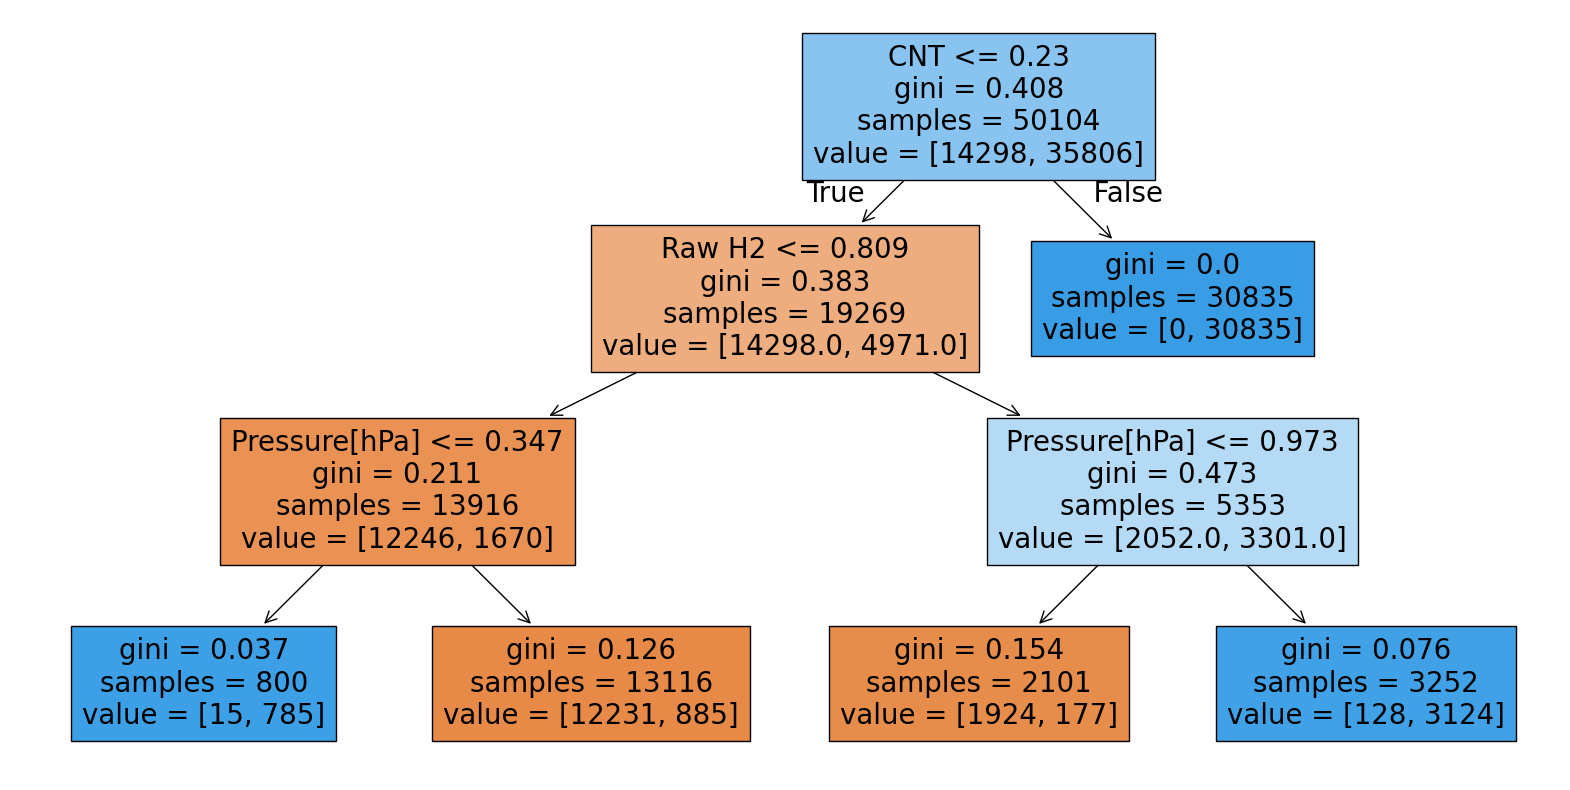

In [90]:
plt.figure(figsize=(20,10))
plot_tree(dt_clf, filled=True, feature_names=X_clf.columns)
plt.show()

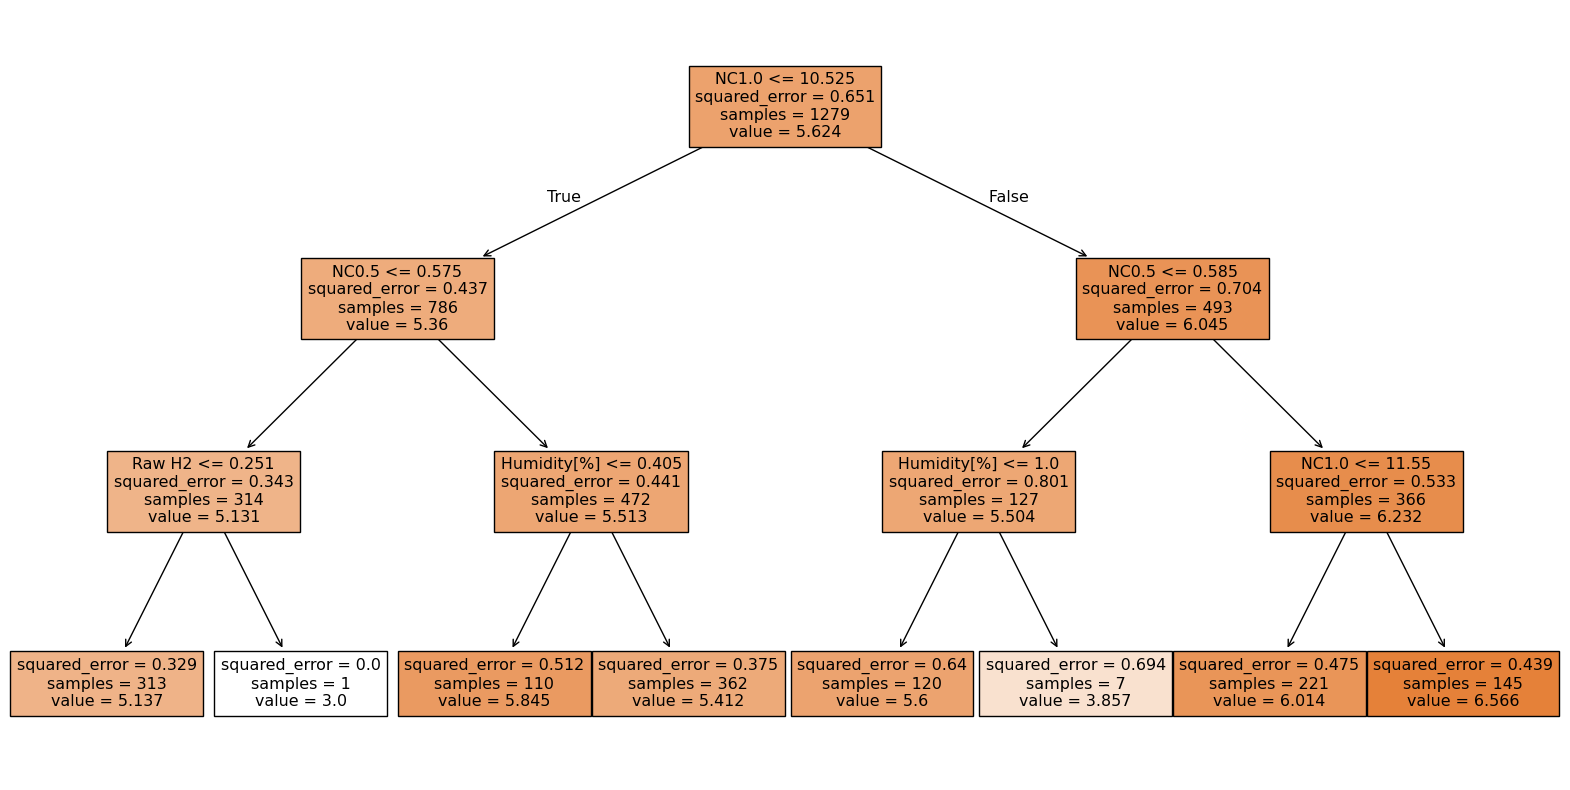

In [91]:
plt.figure(figsize=(20,10))
plot_tree(dt_reg, filled=True, feature_names=X_clf.columns)
plt.show()

## Подбор гиперпараметров

In [92]:
import optuna
from sklearn.model_selection import cross_val_score

In [93]:
def objective(trial):
    param = {
        'max_depth': trial.suggest_int('max_depth', 2, 32),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy'])
    }
    model = DecisionTreeClassifier(**param)
    return cross_val_score(model, X_train_clf, y_train_clf, n_jobs=-1, cv=5).mean()

In [94]:
study_clf = optuna.create_study(direction='maximize')
study_clf.optimize(objective, n_trials=15)
study_clf.best_params

[I 2026-04-13 12:33:46,873] A new study created in memory with name: no-name-b5f883a9-1c30-43ba-9b31-9f34262e6500
[I 2026-04-13 12:33:48,178] Trial 0 finished with value: 0.9997405448558029 and parameters: {'max_depth': 29, 'min_samples_split': 9, 'criterion': 'gini'}. Best is trial 0 with value: 0.9997405448558029.
[I 2026-04-13 12:33:49,222] Trial 1 finished with value: 0.999760502943818 and parameters: {'max_depth': 23, 'min_samples_split': 2, 'criterion': 'gini'}. Best is trial 1 with value: 0.999760502943818.
[I 2026-04-13 12:33:50,102] Trial 2 finished with value: 0.9257145881871622 and parameters: {'max_depth': 2, 'min_samples_split': 13, 'criterion': 'gini'}. Best is trial 1 with value: 0.999760502943818.
[I 2026-04-13 12:33:50,215] Trial 3 finished with value: 0.9998403352958786 and parameters: {'max_depth': 8, 'min_samples_split': 4, 'criterion': 'entropy'}. Best is trial 3 with value: 0.9998403352958786.
[I 2026-04-13 12:33:50,306] Trial 4 finished with value: 0.999760502943

{'max_depth': 8, 'min_samples_split': 4, 'criterion': 'entropy'}

In [95]:
def objective(trial):
    param = {
        'max_depth': trial.suggest_int('max_depth', 2, 64),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 50),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 50),

        'criterion': trial.suggest_categorical('criterion', ['squared_error', 'friedman_mse'])
    }
    
    model = DecisionTreeRegressor(**param)
    
    return cross_val_score(model, X_train_reg, y_train_reg, scoring='r2', n_jobs=-1, cv=5).mean()


In [96]:
study_reg = optuna.create_study(direction='maximize')
study_reg.optimize(objective, n_trials=50)

[I 2026-04-13 12:33:52,908] A new study created in memory with name: no-name-4616e96e-2726-464e-b770-8b4a157f53d1
[I 2026-04-13 12:33:52,922] Trial 0 finished with value: 0.2838859086169405 and parameters: {'max_depth': 4, 'min_samples_split': 48, 'min_samples_leaf': 31, 'criterion': 'friedman_mse'}. Best is trial 0 with value: 0.2838859086169405.
[I 2026-04-13 12:33:52,936] Trial 1 finished with value: 0.29036915805913965 and parameters: {'max_depth': 29, 'min_samples_split': 10, 'min_samples_leaf': 34, 'criterion': 'squared_error'}. Best is trial 1 with value: 0.29036915805913965.
[I 2026-04-13 12:33:52,948] Trial 2 finished with value: 0.26142014414900094 and parameters: {'max_depth': 39, 'min_samples_split': 30, 'min_samples_leaf': 5, 'criterion': 'friedman_mse'}. Best is trial 1 with value: 0.29036915805913965.
[I 2026-04-13 12:33:52,961] Trial 3 finished with value: 0.2952346881148471 and parameters: {'max_depth': 34, 'min_samples_split': 12, 'min_samples_leaf': 23, 'criterion': 

## Метрики

### Регрессия

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [98]:
best_dt_reg = DecisionTreeRegressor(**study_reg.best_params).fit(X_train_reg, y_train_reg)
reg_pred = best_dt_reg.predict(X_test_reg)

MAE

In [99]:
mean_absolute_error(y_test_reg, reg_pred)

0.48661304189645127

MSE

In [100]:
mean_squared_error(y_test_reg, reg_pred)

0.4146297090531251

R2

In [101]:
r2_score(y_test_reg, reg_pred)

0.36553023495509496

### Классификация

In [102]:
from sklearn.metrics import classification_report, roc_auc_score

In [103]:
best_dt_clf = DecisionTreeClassifier(**study_clf.best_params).fit(X_train_clf, y_train_clf)
clf_preds = best_dt_clf.predict(X_test_clf)

In [104]:
print(classification_report(y_test_clf, clf_preds))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3575
         1.0       1.00      1.00      1.00      8951

    accuracy                           1.00     12526
   macro avg       1.00      1.00      1.00     12526
weighted avg       1.00      1.00      1.00     12526



In [105]:
roc_auc_score(y_test_clf, clf_preds, multi_class='ovr')

0.9997202797202797

## Модели ансамблей

### Регрессия

In [106]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import BaggingRegressor, GradientBoostingRegressor
import optuna
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import re

def objective_reg(trial):
    model_type = trial.suggest_categorical('model', ['Bagging', 'GBR', 'XGB', 'LGBM', 'CatBoost'])
    
    if model_type == 'Bagging':
        model = BaggingRegressor(n_estimators=trial.suggest_int('n_est_bag', 10, 50), random_state=42)
    elif model_type == 'GBR':
        model = GradientBoostingRegressor(learning_rate=trial.suggest_float('lr_gbr', 0.01, 0.3), n_estimators=100)
    elif model_type == 'XGB':
        model = XGBRegressor(n_estimators=100, learning_rate=trial.suggest_float('lr_xgb', 0.01, 0.3))
    elif model_type == 'LGBM':
        model = LGBMRegressor(n_estimators=100, learning_rate=trial.suggest_float('lr_lgbm', 0.01, 0.3), verbosity=-1)
    elif model_type == 'CatBoost':
        model = CatBoostRegressor(iterations=100, learning_rate=trial.suggest_float('lr_cat', 0.01, 0.3), silent=True)
    
    score = cross_val_score(model, X_train_reg, y_train_reg, cv=3, scoring='neg_mean_squared_error').mean()
    return score

X_train_reg.columns = [re.sub(r'[^\w\s]', '_', col) for col in X_train_reg.columns]
study_reg = optuna.create_study(direction='maximize')
study_reg.optimize(objective_reg, n_trials=20)
study_reg.best_params

[I 2026-04-13 12:33:53,784] A new study created in memory with name: no-name-20d6f007-b6ea-4b8e-99cd-695f50cf68b3
[I 2026-04-13 12:33:54,046] Trial 0 finished with value: -0.4230902687607767 and parameters: {'model': 'GBR', 'lr_gbr': 0.1927172665984696}. Best is trial 0 with value: -0.4230902687607767.
[I 2026-04-13 12:33:54,137] Trial 1 finished with value: -0.39839775875155875 and parameters: {'model': 'Bagging', 'n_est_bag': 13}. Best is trial 1 with value: -0.39839775875155875.
[I 2026-04-13 12:33:54,395] Trial 2 finished with value: -0.4253539821757692 and parameters: {'model': 'GBR', 'lr_gbr': 0.26286383347180625}. Best is trial 1 with value: -0.39839775875155875.
[I 2026-04-13 12:33:55,408] Trial 3 finished with value: -0.38977606941781345 and parameters: {'model': 'LGBM', 'lr_lgbm': 0.03581759349439705}. Best is trial 3 with value: -0.38977606941781345.
[I 2026-04-13 12:33:55,526] Trial 4 finished with value: -0.4056215003845758 and parameters: {'model': 'CatBoost', 'lr_cat': 0

{'model': 'Bagging', 'n_est_bag': 32}

In [107]:
best_params = study_reg.best_params
model_type = best_params.pop('model')

if model_type == 'Bagging':
    final_model = BaggingRegressor(n_estimators=best_params['n_est_bag'], random_state=42)
elif model_type == 'GBR':
    final_model = GradientBoostingRegressor(learning_rate=best_params['lr_gbr'], n_estimators=100)
elif model_type == 'XGB':
    final_model = XGBRegressor(n_estimators=100, learning_rate=best_params['lr_xgb'])
elif model_type == 'LGBM':
    final_model = LGBMRegressor(n_estimators=100, learning_rate=best_params['lr_lgbm'], verbosity=-1)
elif model_type == 'CatBoost':
    final_model = CatBoostRegressor(iterations=100, learning_rate=best_params['lr_cat'], silent=True)

final_model.fit(X_train_reg, y_train_reg)
new_reg_pred = final_model.predict(X_test_reg)

In [108]:
mean_absolute_error(y_test_reg, new_reg_pred)

0.426953125

In [109]:
mean_squared_error(y_test_reg, new_reg_pred)

0.309759521484375

In [110]:
r2_score(y_test_reg, new_reg_pred)

0.5260034519344282

## Классификация

In [111]:
from sklearn.ensemble import BaggingClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

def objective_clf(trial):
    model_type = trial.suggest_categorical('model', ['Bagging', 'GBC', 'XGB', 'LGBM', 'CatBoost'])
    
    if model_type == 'Bagging':
        model = BaggingClassifier(n_estimators=trial.suggest_int('n_est_bag', 10, 50))
    elif model_type == 'GBC':
        model = GradientBoostingClassifier(n_estimators=100)
    elif model_type == 'XGB':
        model = XGBClassifier(n_estimators=100)
    elif model_type == 'LGBM':
        model = LGBMClassifier(n_estimators=100, verbosity=-1)
    elif model_type == 'CatBoost':
        model = CatBoostClassifier(iterations=100, silent=True)
        
    return cross_val_score(model, X_train_clf, y_train_clf, cv=3, scoring='accuracy').mean()

X_train_clf.columns = [re.sub(r'[^\w\s]', '_', col) for col in X_train_clf.columns]
study_clf = optuna.create_study(direction='maximize')
study_clf.optimize(objective_clf, n_trials=15)


[I 2026-04-13 12:34:01,072] A new study created in memory with name: no-name-6c78420d-4b68-4273-bd0e-a2d07bf8a95d
[I 2026-04-13 12:34:01,501] Trial 0 finished with value: 0.9997604957736291 and parameters: {'model': 'CatBoost'}. Best is trial 0 with value: 0.9997604957736291.
[I 2026-04-13 12:34:01,928] Trial 1 finished with value: 0.9997604957736291 and parameters: {'model': 'CatBoost'}. Best is trial 0 with value: 0.9997604957736291.
[I 2026-04-13 12:34:02,355] Trial 2 finished with value: 0.9997604957736291 and parameters: {'model': 'CatBoost'}. Best is trial 0 with value: 0.9997604957736291.
[I 2026-04-13 12:34:02,779] Trial 3 finished with value: 0.9997604957736291 and parameters: {'model': 'CatBoost'}. Best is trial 0 with value: 0.9997604957736291.
[I 2026-04-13 12:34:03,956] Trial 4 finished with value: 0.9997405416689302 and parameters: {'model': 'Bagging', 'n_est_bag': 11}. Best is trial 0 with value: 0.9997604957736291.
[I 2026-04-13 12:34:05,301] Trial 5 finished with value

In [112]:
best_params = study_clf.best_params
model_type = best_params.pop('model')

if model_type == 'Bagging':
    final_clf = BaggingClassifier(n_estimators=best_params['n_est_bag'])
elif model_type == 'GBC':
    final_clf = GradientBoostingClassifier(n_estimators=100)
elif model_type == 'XGB':
    final_clf = XGBClassifier(n_estimators=100)
elif model_type == 'LGBM':
    final_clf = LGBMClassifier(n_estimators=100, verbosity=-1)
elif model_type == 'CatBoost':
    final_clf = CatBoostClassifier(iterations=100, silent=True)

final_clf.fit(X_train_clf, y_train_clf)
X_test_clf.columns = [re.sub(r'[^\w\s]', '_', col) for col in X_test_clf.columns]
new_clf_pred = final_clf.predict(X_test_clf)

In [113]:
print(classification_report(y_test_clf, clf_preds))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3575
         1.0       1.00      1.00      1.00      8951

    accuracy                           1.00     12526
   macro avg       1.00      1.00      1.00     12526
weighted avg       1.00      1.00      1.00     12526



## Реализация дерева решений основанного на алгоритме CART

In [114]:
from CART_dt import CARTClassifier, CARTRegressor

### Классификация

In [115]:
clf = CARTClassifier(max_depth=3)
clf.fit(X_train_clf, y_train_clf)

In [116]:
clf_pred = clf.predict(X_test_clf)

In [117]:
print(classification_report(y_test_clf, clf_pred))

              precision    recall  f1-score   support

         0.0       0.93      0.99      0.96      3575
         1.0       1.00      0.97      0.98      8951

    accuracy                           0.98     12526
   macro avg       0.96      0.98      0.97     12526
weighted avg       0.98      0.98      0.98     12526



In [118]:
reg = CARTRegressor(max_depth=5)
reg.fit(X_train_reg, y_train_reg)

In [119]:
reg_pred = reg.predict(X_test_reg)

In [120]:
mean_absolute_error(y_test_reg, reg_pred)

0.4916684825601216

In [121]:
mean_squared_error(y_test_reg, reg_pred)

0.4092610720340294

In [122]:
r2_score(y_test_reg, reg_pred)

0.37374536714110185

## Реализация GradientBoosting

In [1]:
from gradient_boosting import CustomGradientBoosting

In [12]:
gb = CustomGradientBoosting()
gb.fit(X_train_reg, y_train_reg)

,n_estimators,100
,learning_rate,0.1
,max_depth,3


In [13]:
gb_pred = gb.predict(X_test_reg)

In [14]:
gb_pred

array([5.34164696, 5.02253239, 5.27830831, 5.28468346, 5.77887998,
       5.11920908, 5.18376144, 5.16781189, 5.8130402 , 5.83079071,
       6.33743436, 5.46356724, 5.54390044, 5.33689479, 5.49796797,
       6.40130911, 5.42191544, 5.69126019, 6.95512964, 5.33030097,
       4.99921867, 5.45002255, 5.44378116, 5.65625261, 5.56620386,
       5.54153004, 6.3636741 , 5.40553206, 5.3206026 , 5.9428647 ,
       5.33042931, 5.33694181, 5.80304656, 5.24678655, 5.69822319,
       5.06399515, 6.11045763, 5.9309642 , 5.53628299, 5.96820568,
       5.34825274, 5.24780273, 6.40337529, 5.26347348, 5.6519205 ,
       5.76563746, 6.27616498, 5.48026726, 5.04639846, 5.57188578,
       4.9185121 , 5.18906342, 5.59725169, 6.49249676, 5.16048365,
       5.27335981, 6.10595032, 5.95364341, 5.71254724, 5.31181017,
       5.69252813, 6.12278135, 5.30300457, 5.19067538, 6.59981582,
       5.2940374 , 6.6224956 , 5.39947049, 6.62094879, 5.31487175,
       6.15058751, 5.2281414 , 5.8109551 , 5.48230262, 6.44812

In [17]:
mean_absolute_error(y_test_reg, gb_pred)

0.48603405659649584

In [18]:
mean_squared_error(y_test_reg, gb_pred)

0.363283131050452

In [19]:
r2_score(y_test_reg, gb_pred)

0.4441011877110195

## Вывод

Для классификации все методы отработали хорошо, f1_score был везде близок к единице.

Метрики для задачи регрессии везде получились низкими, но лучший результат показали модели ансамблей, а конкретно Bagging. Кастомный GradientBoosting оказался на втором месте.